# NB01 — Data Prep: Clean, De-duplicate, Split (LEAKAGE-CONTROLLED)

**Run location:** LOCAL MAC (no GPU, no model files needed)

**Purpose:** Produce clean, de-duplicated, leakage-free splits for all four task variants
(Ben-Sarc binary, BanglaSarc binary, BanglaSarc3 binary, BanglaSarc3 ternary).

**Why this notebook matters most:** v1 split *before* de-duplicating, so duplicate
comments leaked across train/val/test and inflated scores. Here we **de-duplicate
BEFORE splitting** and **hard-assert** that train/val/test never share a (normalized)
text. The notebook fails loudly if any leakage remains.

**Outputs**
- `01_data/interim/cleaned/*_clean.csv` — de-duplicated, schema-unified
- `01_data/processed/{binary,ternary}/*.csv` — task variants
- `01_data/interim/splits/*_{train,val,test}.csv` — leakage-checked splits
- `04_outputs/tables/01_dedup_report.csv`, `01_cross_corpus_overlap.csv`, `01_split_summary.csv`
- `04_outputs/figures/01_class_distribution.png`, `01_text_length_distribution.png`


In [1]:
# === NB01 config + imports ===
import os, re, json, unicodedata
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# ---- Config (edit if needed) ----
SEED = 42
NEAR_DUP = False          # False = exact-key dedup; True = also collapse punctuation/elongation
CONFLICT_POLICY = "drop"  # "drop" = remove same-text rows with conflicting labels; "majority" = keep majority

pd.set_option("display.max_columns", 50)
np.random.seed(SEED)
print("Config -> SEED:", SEED, "| NEAR_DUP:", NEAR_DUP, "| CONFLICT_POLICY:", CONFLICT_POLICY)

Config -> SEED: 42 | NEAR_DUP: False | CONFLICT_POLICY: drop


In [2]:
# === Resolve repo paths (works from repo root OR from 02_notebooks/) ===
def find_repo_root(start: Path) -> Path:
    p = start.resolve()
    for _ in range(8):
        if (p / "01_data" / "raw").exists():
            return p
        if p.parent == p:
            break
        p = p.parent
    raise FileNotFoundError(
        "Could not locate repo root (a folder containing 01_data/raw/). "
        f"Started from: {start.resolve()}"
    )

REPO       = find_repo_root(Path.cwd())
RAW        = REPO / "01_data" / "raw"
CLEANED    = REPO / "01_data" / "interim" / "cleaned"
SPLITS     = REPO / "01_data" / "interim" / "splits"
PROC_BIN   = REPO / "01_data" / "processed" / "binary"
PROC_TERN  = REPO / "01_data" / "processed" / "ternary"
TABLES     = REPO / "04_outputs" / "tables"
FIGS       = REPO / "04_outputs" / "figures"
for d in [CLEANED, SPLITS, PROC_BIN, PROC_TERN, TABLES, FIGS]:
    d.mkdir(parents=True, exist_ok=True)

BEN_XLSX    = RAW / "ben_sarc"    / "Ben-Sarc.xlsx"
BSARC_CSV   = RAW / "banglasarc"  / "SarcasDetection.csv"
BSARC3_XLSX = RAW / "banglasarc3" / "BanglaSarc3.xlsx"

print("REPO root:", REPO)
for f in [BEN_XLSX, BSARC_CSV, BSARC3_XLSX]:
    print(("  OK  " if f.exists() else " MISS "), f.relative_to(REPO))
assert BEN_XLSX.exists() and BSARC_CSV.exists() and BSARC3_XLSX.exists(), (
    'One or more raw files missing — check the paths printed above.'
)

REPO root: /Users/sefayet/Desktop/Github/Sarcasm_detection
  OK   01_data/raw/ben_sarc/Ben-Sarc.xlsx
  OK   01_data/raw/banglasarc/SarcasDetection.csv
  OK   01_data/raw/banglasarc3/BanglaSarc3.xlsx


In [3]:
# === Helpers: column resolution, text normalization, label canonicalization ===
def pick_col(df, candidates, role, dataset):
    norm_map = {c.strip().lower(): c for c in df.columns}
    for cand in candidates:
        if cand.strip().lower() in norm_map:
            return norm_map[cand.strip().lower()]
    raise KeyError(
        f"[{dataset}] Could not find a '{role}' column. "
        f"Tried {candidates}. Actual columns: {list(df.columns)}"
    )

_ZW = dict.fromkeys(map(ord, "\u200b\u200c\u200d\ufeff"), None)  # zero-width chars

def norm_key(t: str) -> str:
    # Used for LEAKAGE DETECTION ONLY — never replaces the modeled text.
    t = unicodedata.normalize("NFC", str(t))
    t = t.translate(_ZW)
    t = re.sub(r"\s+", " ", t).strip().casefold()
    return t

def near_key(t: str) -> str:
    # More aggressive: drop punctuation/emoji + collapse 3+ char repeats.
    t = norm_key(t)
    t = re.sub(r"[^\w\s]", "", t, flags=re.UNICODE)
    t = re.sub(r"(.)\1{2,}", r"\1", t)
    t = re.sub(r"\s+", " ", t).strip()
    return t

def to_binary(v):
    if pd.isna(v): return None
    s = str(v).strip().lower()
    if s in {"1", "1.0"}: return "Sarcastic"
    if s in {"0", "0.0"}: return "Non-Sarcastic"
    if "non" in s:  return "Non-Sarcastic"   # check 'non' before 'sarc'
    if "sarc" in s: return "Sarcastic"
    return None

def to_ternary(v):
    if pd.isna(v): return None
    s = str(v).strip().lower()
    if "neutral" in s: return "Neutral"
    if "non" in s:     return "Non-Sarcastic"
    if "sarc" in s:    return "Sarcastic"
    return None

In [4]:
# === Load raw datasets and unify into common schema ===
def load_clean(path, dataset, text_cands, label_cands, label_fn):
    if path.suffix.lower() in {".xlsx", ".xls"}:
        xl = pd.ExcelFile(path)
        print(f"[{dataset}] sheets: {xl.sheet_names} -> using '{xl.sheet_names[0]}'")
        df = xl.parse(xl.sheet_names[0])
    else:
        df = pd.read_csv(path)
    print(f"[{dataset}] raw shape: {df.shape} | columns: {list(df.columns)}")

    tcol = pick_col(df, text_cands, "text", dataset)
    lcol = pick_col(df, label_cands, "label", dataset)
    print(f"[{dataset}] using text col = '{tcol}', label col = '{lcol}'")

    out = pd.DataFrame()
    out["text"]           = df[tcol].astype(str)
    out["label_original"] = df[lcol].astype(str)
    out["label"]          = df[lcol].map(label_fn)
    out["dataset_name"]   = dataset

    n0 = len(out)
    out["text"] = out["text"].str.strip()
    bad_text  = (out["text"] == "") | (out["text"].str.lower() == "nan")
    bad_label = out["label"].isna()
    nbt, nbl = int(bad_text.sum()), int(bad_label.sum())
    out = out[~(bad_text | bad_label)].reset_index(drop=True)
    print(f"[{dataset}] dropped {nbt} empty-text + {nbl} unmapped-label rows -> {len(out)} kept (of {n0})")
    return out, {"dataset": dataset, "raw_rows": n0, "empty_text_dropped": nbt,
                 "unmapped_label_dropped": nbl, "rows_after_basic_clean": len(out)}

ben_raw, ben_info = load_clean(
    BEN_XLSX, "ben_sarc",
    ["Text", "Comments", "Comment", "comment", "Sentence"],
    ["Polarity", "Label", "Sarcasm", "Class", "label"], to_binary)

bsarc_raw, bsarc_info = load_clean(
    BSARC_CSV, "banglasarc",
    ["Comments", "Comment", "Text", "comment", "Sentence"],
    ["Label", "Polarity", "Sarcasm", "Class", "label"], to_binary)

bsarc3_raw, bsarc3_info = load_clean(
    BSARC3_XLSX, "banglasarc3",
    ["Bangla Comments", "Bangla Comment", "Comments", "Comment", "Text", "comment"],
    ["Sarcasm Label", "Label", "Sarcasm", "Class", "label"], to_ternary)

[ben_sarc] sheets: ['Sheet1'] -> using 'Sheet1'
[ben_sarc] raw shape: (25636, 3) | columns: ['id', 'Text', 'Polarity']
[ben_sarc] using text col = 'Text', label col = 'Polarity'
[ben_sarc] dropped 0 empty-text + 0 unmapped-label rows -> 25636 kept (of 25636)
[banglasarc] raw shape: (5112, 3) | columns: ['Unnamed: 0', 'Comments', 'Label']
[banglasarc] using text col = 'Comments', label col = 'Label'
[banglasarc] dropped 0 empty-text + 0 unmapped-label rows -> 5112 kept (of 5112)
[banglasarc3] sheets: ['Sheet1'] -> using 'Sheet1'
[banglasarc3] raw shape: (12089, 3) | columns: ['Bangla Comments', 'English Translation', 'Sarcasm Label']
[banglasarc3] using text col = 'Bangla Comments', label col = 'Sarcasm Label'
[banglasarc3] dropped 17 empty-text + 0 unmapped-label rows -> 12072 kept (of 12089)


In [5]:
# === De-duplication BEFORE splitting (the core leakage fix) ===
def add_keys(df):
    df = df.copy()
    df["norm_key"]  = df["text"].map(norm_key)
    df["dedup_key"] = df["text"].map(near_key) if NEAR_DUP else df["norm_key"]
    return df

def dedup_frame(df, dataset, policy=CONFLICT_POLICY):
    df = add_keys(df)
    n0 = len(df)
    nunq = df.groupby("dedup_key")["label"].transform("nunique")
    conflict_mask   = nunq > 1
    n_conflict_rows = int(conflict_mask.sum())
    n_conflict_keys = int(df.loc[conflict_mask, "dedup_key"].nunique())

    agreeing       = df[~conflict_mask]
    agreeing_dedup = agreeing.drop_duplicates(subset="dedup_key", keep="first")
    n_agree_removed = len(agreeing) - len(agreeing_dedup)

    if policy == "drop":
        kept = agreeing_dedup
        n_conflict_removed = n_conflict_rows
    elif policy == "majority":
        rows = [agreeing_dedup]
        for _, grp in df[conflict_mask].groupby("dedup_key"):
            vc = grp["label"].value_counts()
            if len(vc) >= 2 and vc.iloc[0] == vc.iloc[1]:
                continue  # tie -> drop whole group
            rows.append(grp[grp["label"] == vc.index[0]].iloc[[0]])
        kept = pd.concat(rows, ignore_index=True)
        added_back = len(kept) - len(agreeing_dedup)
        n_conflict_removed = n_conflict_rows - added_back
    else:
        raise ValueError("CONFLICT_POLICY must be 'drop' or 'majority'")

    kept = kept.reset_index(drop=True)
    rep = {"dataset": dataset, "rows_in": n0, "exact_dup_removed": int(n_agree_removed),
           "conflict_keys": n_conflict_keys, "conflict_rows_removed": int(n_conflict_removed),
           "rows_out": len(kept), "near_dup_mode": NEAR_DUP, "conflict_policy": policy}
    print(f"[{dataset}] dedup: {n0} -> {len(kept)} "
          f"(exact dup removed {n_agree_removed}, conflict rows removed {n_conflict_removed})")
    return kept, rep

ben_clean,    ben_dd    = dedup_frame(ben_raw,    "ben_sarc")
bsarc_clean,  bsarc_dd  = dedup_frame(bsarc_raw,  "banglasarc")
bsarc3_clean, bsarc3_dd = dedup_frame(bsarc3_raw, "banglasarc3")

dedup_report = pd.DataFrame([ben_dd, bsarc_dd, bsarc3_dd])
dedup_report.to_csv(TABLES / "01_dedup_report.csv", index=False)
dedup_report

[ben_sarc] dedup: 25636 -> 25623 (exact dup removed 9, conflict rows removed 4)
[banglasarc] dedup: 5112 -> 4635 (exact dup removed 477, conflict rows removed 0)
[banglasarc3] dedup: 12072 -> 11911 (exact dup removed 109, conflict rows removed 52)


,dataset,rows_in,exact_dup_removed,conflict_keys,conflict_rows_removed,rows_out,near_dup_mode,conflict_policy
0,ben_sarc,25636,9,2,4,25623,False,drop
1,banglasarc,5112,477,0,0,4635,False,drop
2,banglasarc3,12072,109,26,52,11911,False,drop


In [6]:
# === Save cleaned (de-duplicated) datasets + show class balance ===
COLS = ["text", "label", "label_original", "dataset_name", "norm_key", "dedup_key"]
ben_clean[COLS].to_csv(CLEANED / "ben_sarc_clean.csv", index=False)
bsarc_clean[COLS].to_csv(CLEANED / "banglasarc_clean.csv", index=False)
bsarc3_clean[COLS].to_csv(CLEANED / "banglasarc3_clean.csv", index=False)

print("Ben-Sarc   :", ben_clean["label"].value_counts().to_dict())
print("BanglaSarc :", bsarc_clean["label"].value_counts().to_dict())
print("BanglaSarc3:", bsarc3_clean["label"].value_counts().to_dict())

Ben-Sarc   : {'Sarcastic': 12812, 'Non-Sarcastic': 12811}
BanglaSarc : {'Non-Sarcastic': 2975, 'Sarcastic': 1660}
BanglaSarc3: {'Neutral': 4001, 'Non-Sarcastic': 3961, 'Sarcastic': 3949}


In [7]:
# === Cross-corpus overlap report (Requirement 2: detect now, remove in NB10) ===
sets = {"ben_sarc":    set(ben_clean["norm_key"]),
        "banglasarc":  set(bsarc_clean["norm_key"]),
        "banglasarc3": set(bsarc3_clean["norm_key"])}
names = list(sets)
mat = pd.DataFrame(index=names, columns=names, dtype=int)
for a in names:
    for b in names:
        mat.loc[a, b] = len(sets[a] & sets[b])
mat.to_csv(TABLES / "01_cross_corpus_overlap.csv")
print("Pairwise shared (normalized) texts across corpora:")
print(mat)
print("\nIn-domain splits are unaffected. NB10 removes these overlaps before transfer eval.")

Pairwise shared (normalized) texts across corpora:
             ben_sarc  banglasarc  banglasarc3
ben_sarc      25623.0         0.0          1.0
banglasarc        0.0      4635.0        277.0
banglasarc3       1.0       277.0      11911.0

In-domain splits are unaffected. NB10 removes these overlaps before transfer eval.


In [8]:
# === Build the four task variants from de-duplicated frames ===
BIN_MAP  = {"Non-Sarcastic": 0, "Sarcastic": 1}
TERN_MAP = {"Non-Sarcastic": 0, "Neutral": 1, "Sarcastic": 2}

def make_binary(df):
    d = df[df["label"].isin(["Non-Sarcastic", "Sarcastic"])].copy()
    d["label_binary"] = d["label"].map(BIN_MAP).astype(int)
    return d[["text", "label_binary", "label_original", "dataset_name", "norm_key", "dedup_key"]]

def make_ternary(df):
    d = df.copy()
    d["label_ternary"] = d["label"].map(TERN_MAP).astype(int)
    return d[["text", "label_ternary", "label_original", "dataset_name", "norm_key", "dedup_key"]]

ben_binary     = make_binary(ben_clean)
bsarc_binary   = make_binary(bsarc_clean)
bsarc3_binary  = make_binary(bsarc3_clean)    # Neutral dropped automatically
bsarc3_ternary = make_ternary(bsarc3_clean)

ben_binary.to_csv(PROC_BIN  / "ben_sarc_binary.csv", index=False)
bsarc_binary.to_csv(PROC_BIN / "banglasarc_binary.csv", index=False)
bsarc3_binary.to_csv(PROC_BIN / "banglasarc3_binary.csv", index=False)
bsarc3_ternary.to_csv(PROC_TERN / "banglasarc3_ternary.csv", index=False)

for name, d, col in [("ben_sarc_binary", ben_binary, "label_binary"),
                     ("banglasarc_binary", bsarc_binary, "label_binary"),
                     ("banglasarc3_binary", bsarc3_binary, "label_binary"),
                     ("banglasarc3_ternary", bsarc3_ternary, "label_ternary")]:
    print(f"{name:22s} n={len(d):6d} | {d[col].value_counts().sort_index().to_dict()}")

ben_sarc_binary        n= 25623 | {0: 12811, 1: 12812}
banglasarc_binary      n=  4635 | {0: 2975, 1: 1660}
banglasarc3_binary     n=  7910 | {0: 3961, 1: 3949}
banglasarc3_ternary    n= 11911 | {0: 3961, 1: 4001, 2: 3949}


In [9]:
# === Stratified 80/10/10 splits AFTER dedup, with hard leakage assertions ===
def make_splits(df, label_col, seed=SEED):
    train, temp = train_test_split(df, test_size=0.2, stratify=df[label_col], random_state=seed)
    val, test   = train_test_split(temp, test_size=0.5, stratify=temp[label_col], random_state=seed)
    return train.copy(), val.copy(), test.copy()

def assert_no_leakage(train, val, test, key="dedup_key", tag=""):
    s_tr, s_va, s_te = set(train[key]), set(val[key]), set(test[key])
    assert s_tr.isdisjoint(s_va), f"[{tag}] train and val leak: {len(s_tr & s_va)}"
    assert s_tr.isdisjoint(s_te), f"[{tag}] train and test leak: {len(s_tr & s_te)}"
    assert s_va.isdisjoint(s_te), f"[{tag}] val and test leak: {len(s_va & s_te)}"
    print(f"[{tag}] leakage check PASSED (train/val/test disjoint on '{key}')")

def save_splits(prefix, train, val, test):
    train.to_csv(SPLITS / f"{prefix}_train.csv", index=False)
    val.to_csv(SPLITS   / f"{prefix}_val.csv",   index=False)
    test.to_csv(SPLITS  / f"{prefix}_test.csv",  index=False)

variants = [("ben_sarc_binary",     ben_binary,     "label_binary"),
            ("banglasarc_binary",   bsarc_binary,   "label_binary"),
            ("banglasarc3_binary",  bsarc3_binary,  "label_binary"),
            ("banglasarc3_ternary", bsarc3_ternary, "label_ternary")]

split_rows = []
for prefix, df, lcol in variants:
    tr, va, te = make_splits(df, lcol)
    assert_no_leakage(tr, va, te, key="dedup_key", tag=prefix)
    save_splits(prefix, tr, va, te)
    for sname, part in [("train", tr), ("val", va), ("test", te)]:
        props = part[lcol].value_counts(normalize=True).sort_index().round(4).to_dict()
        split_rows.append({"variant": prefix, "split": sname, "n": len(part),
                           "class_proportions": json.dumps(props)})

split_summary = pd.DataFrame(split_rows)
split_summary.to_csv(TABLES / "01_split_summary.csv", index=False)
split_summary

[ben_sarc_binary] leakage check PASSED (train/val/test disjoint on 'dedup_key')
[banglasarc_binary] leakage check PASSED (train/val/test disjoint on 'dedup_key')
[banglasarc3_binary] leakage check PASSED (train/val/test disjoint on 'dedup_key')
[banglasarc3_ternary] leakage check PASSED (train/val/test disjoint on 'dedup_key')


,variant,split,n,class_proportions
0,ben_sarc_binary,train,20498,"{""0"": 0.5, ""1"": 0.5}"
1,ben_sarc_binary,val,2562,"{""0"": 0.5, ""1"": 0.5}"
2,ben_sarc_binary,test,2563,"{""0"": 0.4998, ""1"": 0.5002}"
3,banglasarc_binary,train,3708,"{""0"": 0.6419, ""1"": 0.3581}"
4,banglasarc_binary,val,463,"{""0"": 0.6415, ""1"": 0.3585}"
5,banglasarc_binary,test,464,"{""0"": 0.6422, ""1"": 0.3578}"
6,banglasarc3_binary,train,6328,"{""0"": 0.5008, ""1"": 0.4992}"
7,banglasarc3_binary,val,791,"{""0"": 0.5006, ""1"": 0.4994}"
8,banglasarc3_binary,test,791,"{""0"": 0.5006, ""1"": 0.4994}"
9,banglasarc3_ternary,train,9528,"{""0"": 0.3326, ""1"": 0.3359, ""2"": 0.3315}"


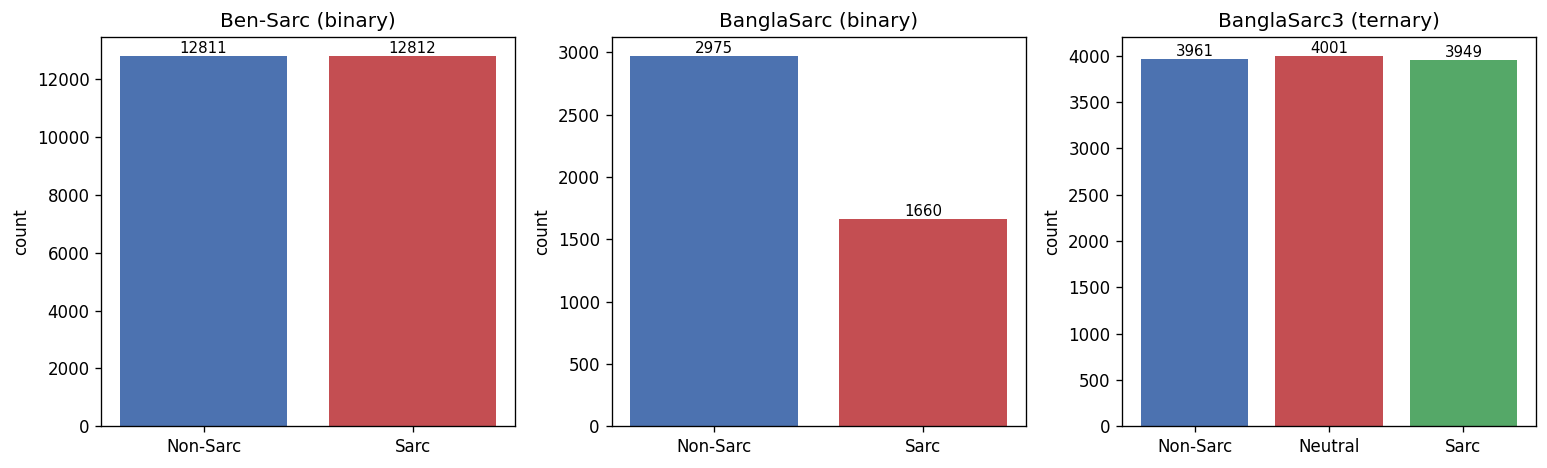

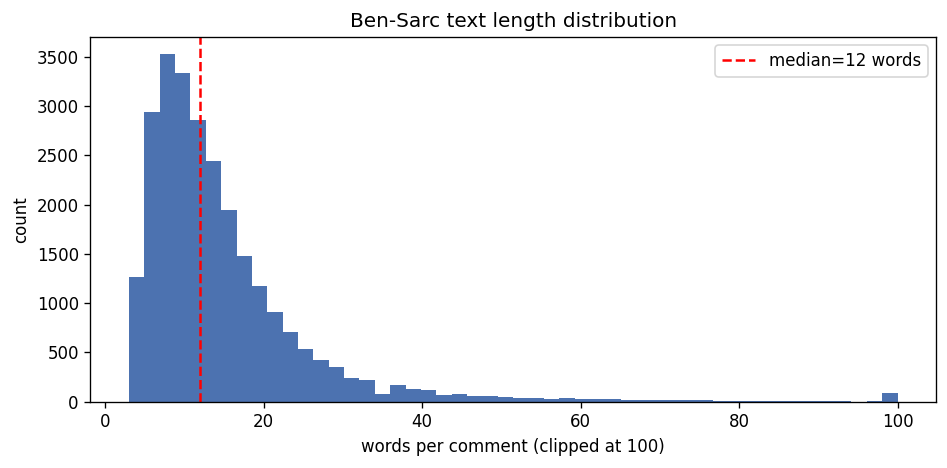

Ben-Sarc word length -> median=12 mean=14.8 95pct=34 max=395


In [10]:
# === EDA figures: class distribution + Ben-Sarc text-length distribution ===
matplotlib.rcParams["figure.dpi"] = 120

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, (title, d, col, mp) in zip(axes, [
    ("Ben-Sarc (binary)",   ben_binary,     "label_binary",  {0:"Non-Sarc", 1:"Sarc"}),
    ("BanglaSarc (binary)", bsarc_binary,   "label_binary",  {0:"Non-Sarc", 1:"Sarc"}),
    ("BanglaSarc3 (ternary)",bsarc3_ternary,"label_ternary", {0:"Non-Sarc", 1:"Neutral", 2:"Sarc"}),
]):
    vc = d[col].value_counts().sort_index()
    ax.bar([mp[i] for i in vc.index], vc.values, color=["#4C72B0","#C44E52","#55A868"][:len(vc)])
    ax.set_title(title); ax.set_ylabel("count")
    for i, v in enumerate(vc.values):
        ax.text(i, v, str(int(v)), ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.savefig(FIGS / "01_class_distribution.png", bbox_inches="tight")
plt.show()

nw = ben_binary["text"].str.split().map(len)
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(nw.clip(upper=100), bins=50, color="#4C72B0")
ax.axvline(nw.median(), color="red", linestyle="--", label=f"median={int(nw.median())} words")
ax.set_xlabel("words per comment (clipped at 100)"); ax.set_ylabel("count")
ax.set_title("Ben-Sarc text length distribution"); ax.legend()
plt.tight_layout()
plt.savefig(FIGS / "01_text_length_distribution.png", bbox_inches="tight")
plt.show()

print("Ben-Sarc word length -> median=%d mean=%.1f 95pct=%d max=%d" %
      (nw.median(), nw.mean(), nw.quantile(0.95), nw.max()))

In [11]:
# === Final self-verification: reload saved splits and re-assert no leakage ===
def reload_and_check(prefix, key="dedup_key"):
    tr = pd.read_csv(SPLITS / f"{prefix}_train.csv")
    va = pd.read_csv(SPLITS / f"{prefix}_val.csv")
    te = pd.read_csv(SPLITS / f"{prefix}_test.csv")
    s_tr, s_va, s_te = set(tr[key]), set(va[key]), set(te[key])
    ok = s_tr.isdisjoint(s_va) and s_tr.isdisjoint(s_te) and s_va.isdisjoint(s_te)
    print(f"  {prefix:22s} train={len(tr):6d} val={len(va):5d} test={len(te):5d} -> leakage-free: {ok}")
    return ok

print("Reloading saved splits and re-checking leakage:")
all_ok = all(reload_and_check(p) for p, _, _ in variants)
print("\nALL SPLITS LEAKAGE-FREE:", all_ok)
assert all_ok, "Leakage detected after reload — STOP and investigate."
print("\nNB01 complete. Clean, de-duplicated, leakage-free splits ready for NB02+.")

Reloading saved splits and re-checking leakage:
  ben_sarc_binary        train= 20498 val= 2562 test= 2563 -> leakage-free: True
  banglasarc_binary      train=  3708 val=  463 test=  464 -> leakage-free: True
  banglasarc3_binary     train=  6328 val=  791 test=  791 -> leakage-free: True
  banglasarc3_ternary    train=  9528 val= 1191 test= 1192 -> leakage-free: True

ALL SPLITS LEAKAGE-FREE: True

NB01 complete. Clean, de-duplicated, leakage-free splits ready for NB02+.
